## Objašnjenje odluka modela

### SHAP

In [ ]:
import pandas as pd
import joblib

df = pd.read_csv("../data/processed/final.csv")
model = joblib.load("../models/final_model.pkl")
threshold = joblib.load("../models/threshold.pkl")

df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,count_submitted_TMA,std_score_CMA,std_score_TMA,total_assessments_CMA,total_assessments_TMA,submission_rate_TMA,submission_rate_CMA,total_clicks,last_active_day,unique_activities
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,2.0,0.0,4.949747,0.0,2.0,1.0,0.0,587.0,87.0,6.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,2.0,0.0,1.414214,0.0,2.0,1.0,0.0,821.0,90.0,6.0
2,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,2.0,0.0,0.707107,0.0,2.0,1.0,0.0,992.0,90.0,7.0
3,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,2.0,0.0,27.577164,0.0,2.0,1.0,0.0,684.0,90.0,7.0
4,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,...,2.0,0.0,7.071068,0.0,2.0,1.0,0.0,1060.0,86.0,7.0


In [2]:
df['target']=df['final_result'].isin(["Fail","Withdrawn"]).astype(int)
df['year']=df['code_presentation'].astype(str).str[:4]

In [3]:
train_df=df[df['year']=="2013"].copy()
test_df=df[df['year']=="2014"].copy()

X_train=train_df.drop(columns=['final_result','target','id_student','year'], errors='ignore')
y_train=train_df['target']

X_test=test_df.drop(columns=['final_result','target','id_student','year'], errors='ignore')
y_test=test_df['target']

In [4]:
preprocessor=model.named_steps['preprocessor']
gb_model=model.named_steps['model']

In [5]:
X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

In [6]:
feature_names = preprocessor.get_feature_names_out()

X_train_shap = pd.DataFrame(X_train_t, columns=feature_names)
X_test_shap = pd.DataFrame(X_test_t, columns=feature_names)

X_train_shap.head()

,num__num_of_prev_attempts,num__studied_credits,num__avg_days_before_deadline_CMA,num__avg_days_before_deadline_TMA,num__avg_score_CMA,num__avg_score_TMA,num__count_submitted_CMA,num__count_submitted_TMA,num__std_score_CMA,num__std_score_TMA,...,cat__imd_band_60-70%,cat__imd_band_70-80%,cat__imd_band_80-90%,cat__imd_band_90-100%,cat__imd_band_Unknown,cat__age_band_0-35,cat__age_band_35-55,cat__age_band_55<=,cat__disability_N,cat__disability_Y
0,-0.355025,4.212351,0.179313,-0.059914,-0.671701,0.576414,-0.569054,-0.030785,-0.246734,-0.130813,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,-0.355025,-0.482036,0.179313,-0.294261,-0.671701,0.046804,-0.569054,-0.030785,-0.246734,-0.673997,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-0.355025,-0.482036,0.179313,0.174434,-0.671701,0.152726,-0.569054,-0.030785,-0.246734,-0.782634,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.355025,-0.482036,0.179313,-2.403388,-0.671701,-0.779386,-0.569054,-0.030785,-0.246734,3.345566,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,-0.355025,-0.482036,0.179313,-0.997304,-0.671701,0.258648,-0.569054,-0.030785,-0.246734,0.195098,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [7]:
import shap 
explainer = shap.Explainer(gb_model, X_train_shap)
shap_values = explainer(X_test_shap,check_additivity=False)

Background dataset has 11055 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=11055 when initializing the masker.
 96%|=================== | 13885/14507 [00:17<00:00]       

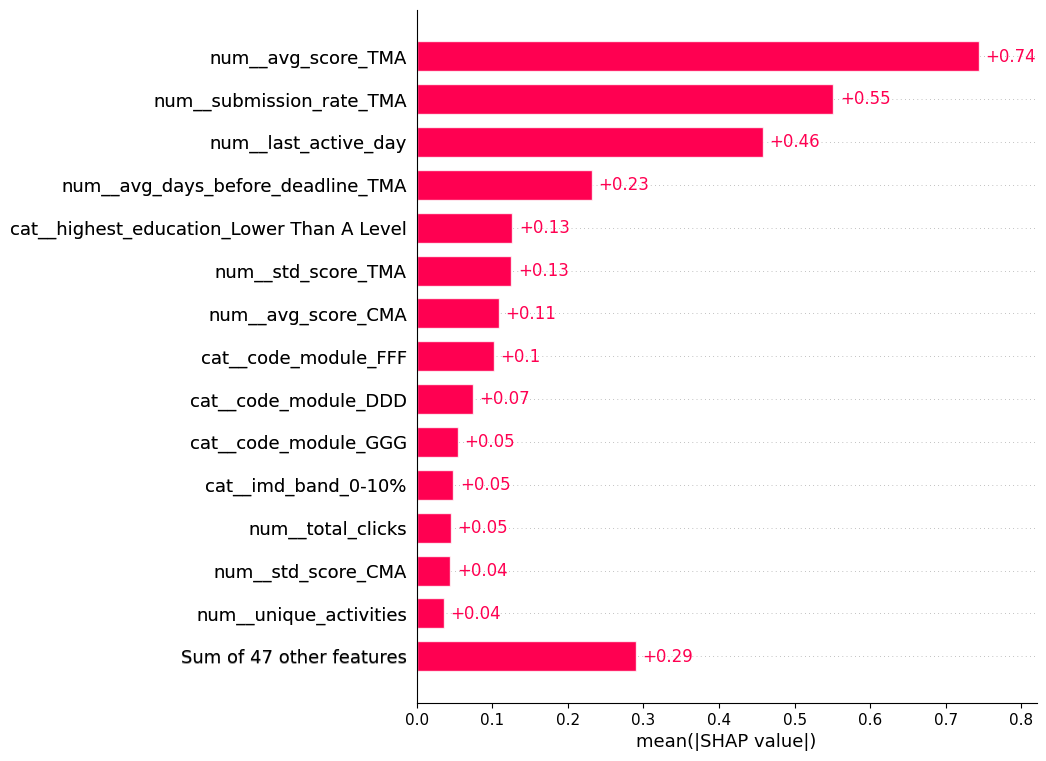

In [8]:
shap.plots.bar(shap_values, max_display=15)

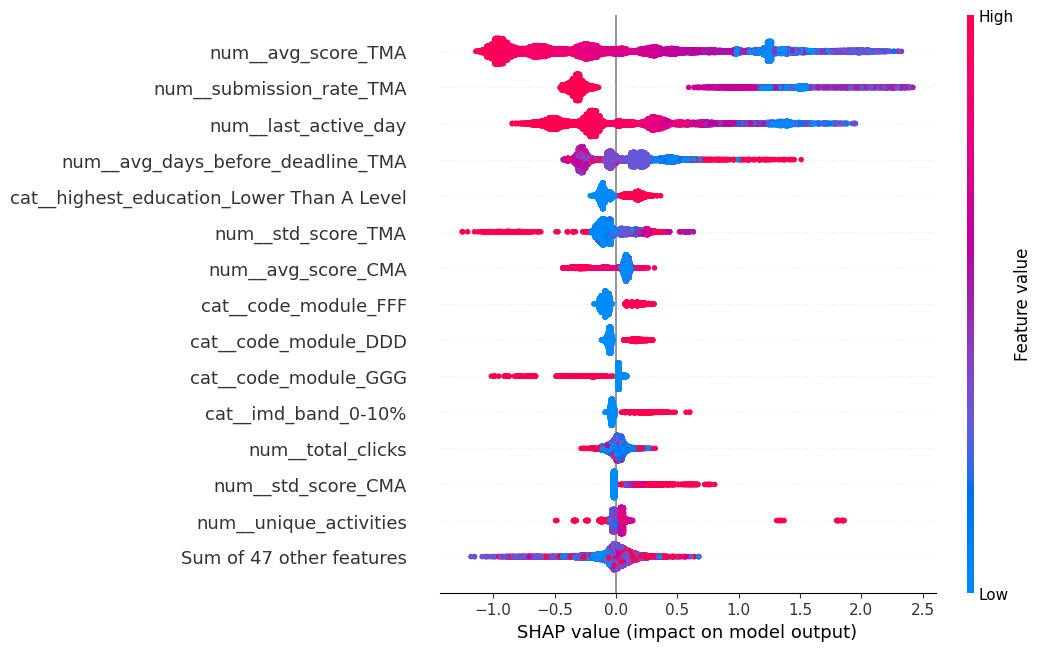

In [9]:
shap.plots.beeswarm(shap_values, max_display=15)

In [10]:
student_index = 0
X_test.iloc[[student_index]]

student_proba = model.predict_proba(X_test.iloc[[student_index]])[:, 1][0]
student_pred = int(student_proba >= threshold)

print("Verovatnoća rizika:", round(student_proba, 4))
print("Predikcija:", "Rizičan student" if student_pred == 1 else "Uspešan student")
print("Stvarna klasa:", y_test.iloc[student_index])

Verovatnoća rizika: 0.2653
Predikcija: Uspešan student
Stvarna klasa: 0


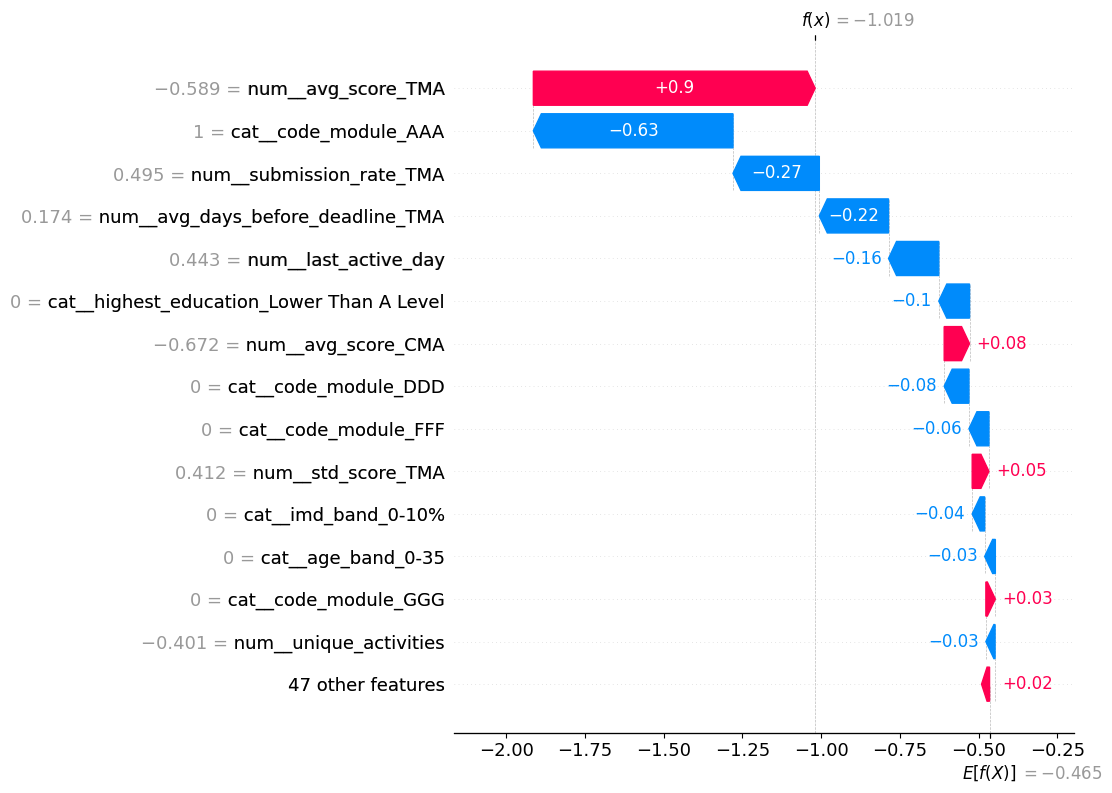

In [11]:
shap.plots.waterfall(shap_values[student_index], max_display=15)

### LIME

In [12]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_shap),
    feature_names=feature_names,
    class_names=["Uspešan", "Rizičan"],
    mode="classification"
)

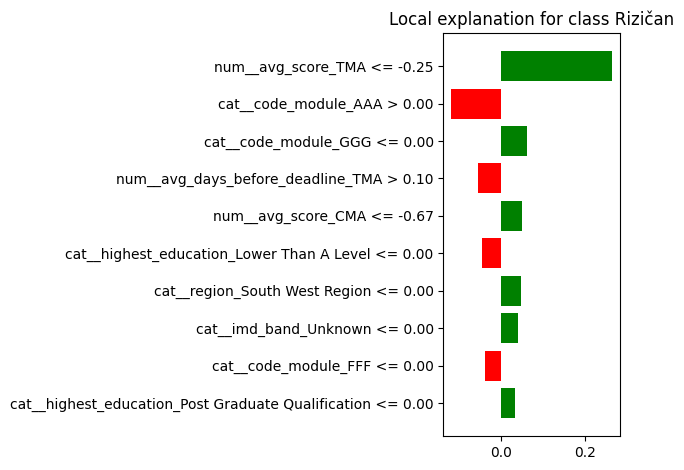

In [13]:
import matplotlib.pyplot as plt

student_index = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_shap.iloc[student_index].values,
    predict_fn=gb_model.predict_proba,
    num_features=10
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

## Counterfactual 

In [14]:
import subprocess
subprocess.run(["pip", "install", "dice-ml"], check=True)

CompletedProcess(args=['pip', 'install', 'dice-ml'], returncode=0)

In [15]:
X = df.drop(columns=["final_result", "target", "id_student", "year"],errors="ignore")
y = df["target"]

dice_data = X.copy()
dice_data["target"] = y.values

num_col_dice = X.select_dtypes(include="number").columns.tolist()

In [16]:
import dice_ml
from dice_ml import Dice

d = dice_ml.Data(
    dataframe=dice_data,
    continuous_features=num_col_dice,
    outcome_name="target"
)
m = dice_ml.Model(model=model, backend="sklearn")
exp = Dice(d, m, method="random")

In [17]:
y_proba_test = model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= threshold).astype(int)
true_positive_indices = np.where((y_test.values == 1) & (y_pred_test == 1))[0]
print("Broj stvarno rizičnih studenata koje je model prepoznao kao rizične:", len(true_positive_indices))

student_position = true_positive_indices[0]
query_instance = X_test.iloc[[student_position]]
print("Stvarna klasa:", y_test.iloc[student_position])
print("Predikcija modela:", y_pred_test[student_position])
print("Verovatnoća rizika:", round(y_proba_test[student_position], 4))
query_instance


Broj stvarno rizičnih studenata koje je model prepoznao kao rizične: 4055
Stvarna klasa: 1
Predikcija modela: 1
Verovatnoća rizika: 0.5005


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,count_submitted_TMA,std_score_CMA,std_score_TMA,total_assessments_CMA,total_assessments_TMA,submission_rate_TMA,submission_rate_CMA,total_clicks,last_active_day,unique_activities
370,AAA,2014J,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,1,60,N,...,2.0,0.0,1.414214,0.0,2.0,1.0,0.0,3.0,10.0,1.0


In [18]:
features_to_vary = [
    "avg_score_TMA",
    "submission_rate_TMA",
    "total_clicks",
    "last_active_day",
    "unique_activities",
    "count_submitted_TMA",
    "avg_days_before_deadline_TMA"
]

dice_exp = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class=0,
    features_to_vary=features_to_vary
)

dice_exp.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  2.78it/s]

Query instance (original outcome : 1)


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,std_score_CMA,std_score_TMA,total_assessments_CMA,total_assessments_TMA,submission_rate_TMA,submission_rate_CMA,total_clicks,last_active_day,unique_activities,target
0,AAA,2014J,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,1,60,N,...,0.0,1.414214,0.0,2.0,1.0,0.0,3.0,10.0,1.0,1



Diverse Counterfactual set (new outcome: 0)


,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,std_score_CMA,std_score_TMA,total_assessments_CMA,total_assessments_TMA,submission_rate_TMA,submission_rate_CMA,total_clicks,last_active_day,unique_activities,target
0,AAA,2014J,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,1,60,N,...,0.0,1.414214,0.0,2.0,1.0,0.0,3.0,56.3,1.0,0
1,AAA,2014J,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,1,60,N,...,0.0,1.414214,0.0,2.0,1.0,0.0,3.0,10.0,1.0,0
2,AAA,2014J,F,East Anglian Region,A Level or Equivalent,70-80%,0-35,1,60,N,...,0.0,1.414214,0.0,2.0,1.0,0.0,3.0,85.2,1.0,0


In [19]:
cf_df = dice_exp.cf_examples_list[0].final_cfs_df

comparison = pd.concat(
    [query_instance, cf_df],
    keys=["Originalni student", "Kontrafaktualni primeri"]
)

comparison[[
    "avg_score_TMA",
    "submission_rate_TMA",
    "total_clicks",
    "last_active_day",
    "unique_activities",
    "count_submitted_TMA",
    "avg_days_before_deadline_TMA"
]]

avg_score_TMA  submission_rate_TMA  total_clicks  \
Originalni student      370           67.0                  1.0           3.0   
Kontrafaktualni primeri 0             67.0                  1.0           3.0   
                        1             67.0                  1.0           3.0   
                        2             67.0                  1.0           3.0   

                             last_active_day  unique_activities  \
Originalni student      370             10.0                1.0   
Kontrafaktualni primeri 0               56.3                1.0   
                        1               10.0                1.0   
                        2               85.2                1.0   

                             count_submitted_TMA  avg_days_before_deadline_TMA  
Originalni student      370                  2.0                          37.5  
Kontrafaktualni primeri 0                    2.0                          37.5  
                        1                    0.7                          16.2  
                        2                    2.0                          37.5